<h1> Extracting very coarse ERA5 data and building super simple ML </h1>

Developing towards the Anemoi Keisler 2022 (or at least practicing)

We'll load the coarsest 64 x 32 ERA5 data from the WeatherBench public Google Cloud bucket

Requires at least the packages:
- xarray
- gcsfs
- fsspec
- zarr 
- numpy
- torch
- matplotlib

In [13]:
import numpy as np
import torch 
import torch.nn as nn

# The following are for a ChatGPT-generated message-passing GNN:
from torch_geometric.data import Data
from torch_geometric.utils import dense_to_sparse
from torch_geometric.nn import MessagePassing
import torch.nn.functional as F

import matplotlib.pyplot as plt
import xarray as xr


In [2]:

# This automatically uses gcsfs under the hood
ds = xr.open_zarr(
    #'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr',
    'gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr',
    consolidated=True
)

ds


<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
  * longitude                                         (longitude) float64 512B ...
  * time                                              (time) datetime64[ns] 748kB ...
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>

In [3]:
# Our first dataset will be simply the 500 hPa geopotential

geopotential_500=ds['geopotential'].isel(level=7)

latitudes=ds['latitude']
longitudes=ds['longitude']

geopotential_500, latitudes, longitudes


(<xarray.DataArray 'geopotential' (time: 93544, longitude: 64, latitude: 32)> Size: 766MB
 dask.array<getitem, shape=(93544, 64, 32), dtype=float32, chunksize=(100, 64, 32), chunktype=numpy.ndarray>
 Coordinates:
   * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
     level      int64 8B 500
   * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
   * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
 Attributes:
     long_name:      Geopotential
     short_name:     z
     standard_name:  geopotential
     units:          m**2 s**-2,
 <xarray.DataArray 'latitude' (latitude: 32)> Size: 256B
 array([-87.1875, -81.5625, -75.9375, -70.3125, -64.6875, -59.0625, -53.4375,
        -47.8125, -42.1875, -36.5625, -30.9375, -25.3125, -19.6875, -14.0625,
         -8.4375,  -2.8125,   2.8125,   8.4375,  14.0625,  19.6875,  25.3125,
         30.9375,  36.5625,  42.1875,  47.8125,  53.4375,  59.0625,  64.6875,
         70.3125,

In [4]:
# Let's "hack" even more and take just the last 100 time steps

#geopotential_500=geopotential_500.isel(time=slice(-100, None))


# Improving to 1000 time steps:
geopotential_500=geopotential_500.isel(time=slice(-1000, None)).load()  # Had to include load, otherwise it's caching the old one


# And let's convert to a torch tensor for future use
geo500_data=torch.from_numpy(geopotential_500.values)
geo500_data.shape

torch.Size([1000, 64, 32])

In [5]:
import numpy as np

class Graph:
    def __init__(self, width, height, latitudes=None, longitudes=None, data=None):
        self.width = width
        self.height = height

        if latitudes is None:
            latitudes = np.linspace(90, -90, height)
        if longitudes is None:
            longitudes = np.linspace(0, 360, width, endpoint=False)

        self.latitudes = latitudes
        self.longitudes = longitudes

        # Coordinates and graph structure
        self.coords = np.zeros((width, height, 2), dtype=float)        # (lat, lon)
        self.neighbors = np.zeros((width, height, 4, 2), dtype=int)    # 4 neighbor (i,j) pairs
        
        # Validate and assign data
        if data is not None:
            if data.shape[1:] != (width, height):
                raise ValueError(f"Data shape must be (n_time, {width}, {height}), but got {data.shape}")
            self.data = data
        else:
            self.data = None

        self._build_graph()

    def _build_graph(self):
        for i in range(self.width):
            for j in range(self.height):
                self.coords[i, j] = (self.latitudes[j], self.longitudes[i])

                # 4-neighborhood with periodic boundary conditions
                neighbor_coords = [
                    ((i - 1) % self.width, j),    # left
                    ((i + 1) % self.width, j),    # right
                    (i, (j - 1) % self.height),   # up
                    (i, (j + 1) % self.height)    # down
                ]

                self.neighbors[i, j] = neighbor_coords

    def flat_index(self, i, j):
        return i * self.height + j

    def get_adjacency_matrix(self):
        N = self.width * self.height
        adj = np.zeros((N, N), dtype=int)

        for i in range(self.width):
            for j in range(self.height):
                node_id = self.flat_index(i, j)
                for ni, nj in self.neighbors[i, j]:
                    neighbor_id = self.flat_index(ni, nj)
                    adj[node_id, neighbor_id] = 1
        return adj


In [8]:
graph = Graph(64, 32, latitudes=latitudes, longitudes=longitudes, data=geo500_data)

In [ ]:


example_index=[12,15]
print("Lat/Lon at example index:", graph.coords[example_index[0],example_index[1]])      
print("Neighbors at example index:", graph.neighbors[example_index[0],example_index[1]])
neighbors_example=graph.neighbors[example_index[0],example_index[1]]   
print("Coordinates of neighbors: ", graph.coords[neighbors_example[0][0],neighbors_example[0][1]],
      graph.coords[neighbors_example[1][0],neighbors_example[1][1]],
      graph.coords[neighbors_example[2][0],neighbors_example[2][1]],
      graph.coords[neighbors_example[3][0],neighbors_example[3][1]])


Lat/Lon at example index: [-2.8125 67.5   ]
Neighbors at example index: [[11 15]
 [13 15]
 [12 14]
 [12 16]]
Coordinates of neighbors:  [-2.8125 61.875 ] [-2.8125 73.125 ] [-8.4375 67.5   ] [ 2.8125 67.5   ]


In [7]:
# Sanity check that the graph gives the right coordinates for extracting data:

example_time=0
example_index=[2,20]

graph_coords_example=[graph.coords[example_index[0],example_index[1]]]

print("Our example lat, lon coordinates are: ", graph_coords_example)

data_from_torch_tensor=geo500_data[example_time,example_index[0],example_index[1]]

print("Data from our torch tensor: ", data_from_torch_tensor)

graph_coords_example=graph.coords[example_index[0],example_index[1]]


data_from_original_xarray=geopotential_500.sel(
          time=geopotential_500.time[example_time],
          latitude=graph_coords_example[0],
          longitude=graph_coords_example[1]#,
          #method='nearest'   # optional for float matching
      ).values

print("Data from original xarray dataset with graph coords:",data_from_original_xarray)

difference=data_from_torch_tensor-data_from_original_xarray

print("This difference should be zero up to rounding error: ", difference)


Our example lat, lon coordinates are:  [array([25.3125, 11.25  ])]
Data from our torch tensor:  tensor(57694.7695)
Data from original xarray dataset with graph coords: 57694.77
This difference should be zero up to rounding error:  tensor(0.)


/tmp/ipykernel_106185/2533668588.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  difference=data_from_torch_tensor-data_from_original_xarray


Pre-processing for GNN

In [14]:
# Normalize geopotential data
geo_mean = geo500_data.mean()
geo_std = geo500_data.std()
geo_norm = (geo500_data - geo_mean) / geo_std

# And redefine the graph with normalized values:
graph = Graph(64, 32, latitudes=latitudes, longitudes=longitudes, data=geo_norm)

Let's try a ChatGPT-generated GNN

In [27]:
def make_graphs(graph, geo_tensor):
    """
    Returns list of PyG Data objects (input x, edge_index) and y tensors for t+1
    """
    data_list = []
    target_list = []
    n_time = geo_tensor.shape[0]

    for t in range(n_time - 1):
        data_t = graph_to_pyg(graph, geo_tensor[t])
        target_t = geo_tensor[t + 1].reshape(-1).float()
        data_list.append(data_t)
        target_list.append(target_t)

    return data_list, target_list

In [22]:
class DeepGNN(torch.nn.Module):
    def __init__(self, hidden_dim=64, num_layers=5):
        super().__init__()
        self.input = torch.nn.Linear(1, hidden_dim)
        self.convs = torch.nn.ModuleList([
            MessagePassing(aggr='mean') for _ in range(num_layers)
        ])
        self.linears = torch.nn.ModuleList([
            torch.nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])
        self.output = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        x = F.relu(self.input(x))
        for conv, linear in zip(self.convs, self.linears):
            x = conv.propagate(edge_index=edge_index, x=x)
            x = F.relu(linear(x))
        return self.output(x).squeeze(-1)  # shape (n_nodes,)


In [25]:
# Choose a time step for training
t = 10

# Prepare input graph at time t-1
data_t = graph_to_pyg(graph, geo_norm[t-1])
y_true = geo_norm[t].reshape(-1).float()

# Init model
model = DeepGNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

# Train loop
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    y_pred = model(data_t.x, data_t.edge_index)
    loss = loss_fn(y_pred, y_true)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")



Epoch 000 | Loss: 0.9306
Epoch 010 | Loss: 0.7997
Epoch 020 | Loss: 0.3830
Epoch 030 | Loss: 0.0821
Epoch 040 | Loss: 0.0410
Epoch 050 | Loss: 0.0314
Epoch 060 | Loss: 0.0272
Epoch 070 | Loss: 0.0240
Epoch 080 | Loss: 0.0224
Epoch 090 | Loss: 0.0215
Epoch 100 | Loss: 0.0211
Epoch 110 | Loss: 0.0209
Epoch 120 | Loss: 0.0208
Epoch 130 | Loss: 0.0207
Epoch 140 | Loss: 0.0207
Epoch 150 | Loss: 0.0206
Epoch 160 | Loss: 0.0206
Epoch 170 | Loss: 0.0205
Epoch 180 | Loss: 0.0205
Epoch 190 | Loss: 0.0204
Epoch 200 | Loss: 0.0204
Epoch 210 | Loss: 0.0204
Epoch 220 | Loss: 0.0204
Epoch 230 | Loss: 0.0204
Epoch 240 | Loss: 0.0203
Epoch 250 | Loss: 0.0203
Epoch 260 | Loss: 0.0203
Epoch 270 | Loss: 0.0203
Epoch 280 | Loss: 0.0203
Epoch 290 | Loss: 0.0202
Epoch 300 | Loss: 0.0202
Epoch 310 | Loss: 0.0202
Epoch 320 | Loss: 0.0202
Epoch 330 | Loss: 0.0202
Epoch 340 | Loss: 0.0202
Epoch 350 | Loss: 0.0202
Epoch 360 | Loss: 0.0201
Epoch 370 | Loss: 0.0201
Epoch 380 | Loss: 0.0201
Epoch 390 | Loss: 0.0201


In [26]:
y_pred_denorm = y_pred * geo_std + geo_mean
y_true_denorm = y_true * geo_std + geo_mean

rmse = torch.sqrt(torch.mean((y_pred_denorm - y_true_denorm)**2))
print(f"RMSE (m²/s²): {rmse.item():.2f}")
print(f"RMSE (m):     {rmse.item() / 9.80665:.2f}")


RMSE (m²/s²): 452.67
RMSE (m):     46.16


Let's start building our ML model by using as input/predictor the geo500_data at time t at each point plus its neighbors.

Then we predict geo500_data at t+1.

In [95]:

# Original tensor
geo = geo500_data  # shape (100, 64, 32)

# Inputs: t from 0 to 98 → use geo[t] for prediction of geo[t+1]
x_raw = geo[:-1]  # shape (99, 64, 32)
y = geo[1:]       # shape (99, 64, 32)

# Prepare 5 input channels per point
x_center = x_raw                              # (99, 64, 32)
x_left   = torch.roll(x_raw, shifts=+1, dims=2)  # left neighbor (i-1)
x_right  = torch.roll(x_raw, shifts=-1, dims=2)  # right neighbor (i+1)
x_up     = torch.roll(x_raw, shifts=-1, dims=1)  # up neighbor (j-1)
x_down   = torch.roll(x_raw, shifts=+1, dims=1)  # down neighbor (j+1)

# Stack as new feature dimension
x = torch.stack([x_center, x_left, x_right, x_up, x_down], dim=-1)  # shape: (99, 64, 32, 5)


In [97]:
# Let's again run a sanity check to make sure the data is correct

example_time=0
example_index=[2,20]

x_from_torch_tensor=geo500_data[example_time,example_index[0],example_index[1]]
print(x_from_torch_tensor,x_raw[example_time,example_index[0],example_index[1]])
x_left_from_torch_tensor=geo500_data[example_time,example_index[0],example_index[1]-1]
print(x_left_from_torch_tensor,x_left[example_time,example_index[0],example_index[1]])
x_right_from_torch_tensor=geo500_data[example_time,example_index[0],example_index[1]+1]
print(x_right_from_torch_tensor,x_right[example_time,example_index[0],example_index[1]])
x_up_from_torch_tensor=geo500_data[example_time,example_index[0]+1,example_index[1]]
print(x_up_from_torch_tensor,x_up[example_time,example_index[0],example_index[1]])
x_down_from_torch_tensor=geo500_data[example_time,example_index[0]-1,example_index[1]]
print(x_down_from_torch_tensor,x_down[example_time,example_index[0],example_index[1]])

# And create parameters for reshaping the tensors to (samples, features)

n_times=geo500_data.shape[0]
n_lat=64
n_lon=32
n_features=5

num_samples = (n_times-1) * n_lat * n_lon

print(x.shape, num_samples)

x_flat = x.reshape(num_samples, n_features)
y_flat = y.reshape(num_samples)

print(x_flat.shape, y_flat.shape)

# Checking also that x_up has the same values as x_raw (as it should only be a shifted array/tensor)
print(torch.min(x_up),torch.max(x_up),torch.mean(x_up),torch.std(x_up))
print(torch.min(x_raw),torch.max(x_raw),torch.mean(x_raw),torch.std(x_raw))

tensor(57694.7695) tensor(57694.7695)
tensor(58061.6680) tensor(58061.6680)
tensor(56803.2617) tensor(56803.2617)
tensor(57785.0703) tensor(57785.0703)
tensor(57569.1250) tensor(57569.1250)
torch.Size([999, 64, 32, 5]) 2045952
torch.Size([2045952, 5]) torch.Size([2045952])
tensor(43248.1992) tensor(59019.7930) tensor(54292.7344) tensor(3397.1411)
tensor(43248.1992) tensor(59019.7930) tensor(54292.7227) tensor(3397.1411)


Now we get to the first ML forecast. This is just puked out from ChatGPT, no testing done yet.

In [98]:
from sklearn.model_selection import train_test_split

# Convert to float32 if needed
x_flat = x_flat.float()
y_flat = y_flat.float()

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x_flat, y_flat, test_size=0.2, random_state=42)


NameError: name 'model' is not defined

In [99]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # to match shape (N,) with y


In [100]:
model = SimpleMLP()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Convert to device if needed (e.g., CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
model.to(device)
x_train, x_test = x_train.to(device), x_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)


x_flat.shape, x_test.device

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

print(x_train.device, y_train.device, model.net[0].weight.device)

#print(torch.cuda.is_available())

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#x_train = x_train.to(device)
#y_train = y_train.to(device)
#x_test = x_test.to(device)
#y_test = y_test.to(device)
#model.to(device)

# Training loop
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

    print(f"Epoch {epoch:02d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")



cpu cpu cpu
Epoch 00 | Train Loss: 2841439744.0000 | Test Loss: 2759627776.0000
Epoch 01 | Train Loss: 2759548672.0000 | Test Loss: 2678482688.0000
Epoch 02 | Train Loss: 2678405632.0000 | Test Loss: 2597674240.0000
Epoch 03 | Train Loss: 2597598976.0000 | Test Loss: 2515800576.0000
Epoch 04 | Train Loss: 2515728640.0000 | Test Loss: 2433286144.0000
Epoch 05 | Train Loss: 2433218560.0000 | Test Loss: 2350434048.0000
Epoch 06 | Train Loss: 2350368256.0000 | Test Loss: 2267677952.0000
Epoch 07 | Train Loss: 2267614208.0000 | Test Loss: 2187101184.0000
Epoch 08 | Train Loss: 2187040512.0000 | Test Loss: 2108546688.0000
Epoch 09 | Train Loss: 2108487552.0000 | Test Loss: 2030317824.0000
Epoch 10 | Train Loss: 2030260480.0000 | Test Loss: 1952441984.0000
Epoch 11 | Train Loss: 1952385664.0000 | Test Loss: 1875054336.0000
Epoch 12 | Train Loss: 1874999424.0000 | Test Loss: 1803059968.0000
Epoch 13 | Train Loss: 1803003776.0000 | Test Loss: 1732774272.0000
Epoch 14 | Train Loss: 1732719616.00

In [101]:
from sklearn.ensemble import RandomForestRegressor

# Define model (no fitting here yet)
class SimpleRandomForest:
    def __init__(self, n_estimators=100, max_depth=10):
        self.model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )

    def fit(self, x, y):
        self.model.fit(x, y)

    def predict(self, x):
        return self.model.predict(x)


In [102]:
# x_flat: torch tensor of shape (N, 5)
# y_flat: torch tensor of shape (N,)

x_np = x_flat.cpu().numpy()
y_np = y_flat.cpu().numpy()

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

x_train, x_test, y_train, y_test = train_test_split(x_np, y_np, test_size=0.2, random_state=42)

rf_model = SimpleRandomForest(n_estimators=100, max_depth=10)
rf_model.fit(x_train, y_train)

y_pred = rf_model.predict(x_test)
mse_rf = mean_squared_error(y_test, y_pred)
print(f"Random Forest MSE: {mse_rf:.4f}")


Random Forest MSE: 35444.7104


tensor(228.8092)
(1636761, 5)
793.1516
tensor(836.3105, grad_fn=<SqrtBackward0>)


/tmp/ipykernel_96177/563340539.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(np.sqrt(torch.mean((x_raw-y)**2)))


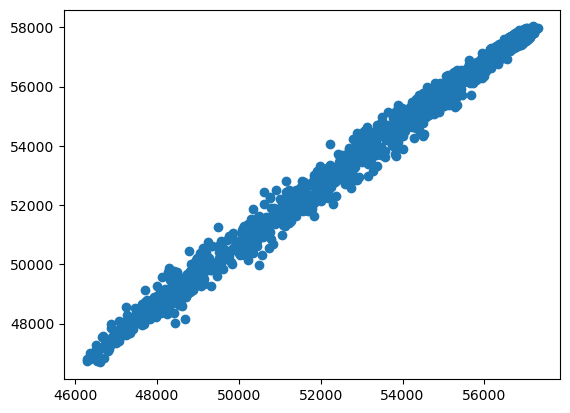

In [103]:

print(np.sqrt(torch.mean((x_raw-y)**2)))

print(x_train.shape)

plt.scatter(model(x[0,:]).detach().numpy(),y[0].detach().numpy())

x_sample_example=model(x[0,:]).detach().numpy()
y_sample_example=y[0].detach().numpy()

#print(x_sample_example.shape,y_sample_example.shape)
print(np.sqrt(np.mean((x_sample_example-y_sample_example)**2)))

print(torch.sqrt(loss))



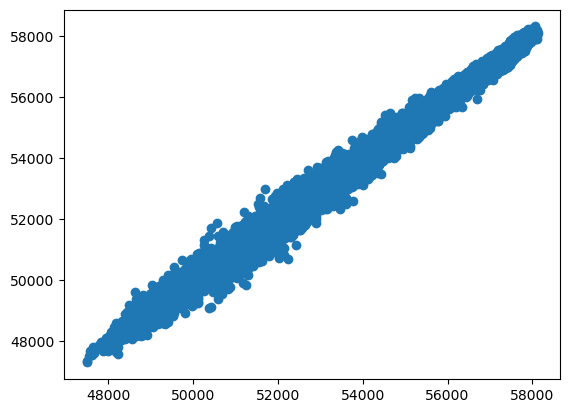

185.41580386249456


In [48]:
plt.scatter(y_pred,y_test)
plt.show()

print(np.sqrt(np.mean((y_pred-y_test)**2)))

In [60]:
n_times_test=20
y_pred_grid = y_pred.reshape(n_times_test, n_lat, n_lon)

ValueError: cannot reshape array of size 40551 into shape (20,64,32)

In [126]:
n_times, n_lat, n_lon, n_features = x.shape
split_idx = int(n_times * 0.8)  # e.g. 79 if n_times=99

# Split in time
x_train = x[:split_idx]    # (79, 64, 32, 5)
x_test  = x[split_idx:]    # (20, 64, 32, 5)
y_train = y[:split_idx]    # (79, 64, 32)
y_test  = y[split_idx:]    # (20, 64, 32)

# Flatten space for ML
x_train_flat = x_train.reshape(-1, n_features)  # (79*64*32, 5)
x_test_flat  = x_test.reshape(-1, n_features)   # (20*64*32, 5)
y_train_flat = y_train.reshape(-1)
y_test_flat  = y_test.reshape(-1)


# Normalize, start with calculating means:
normalizer_mean=torch.mean(x)
normalizer_std=torch.std(x)
x_train_flat = (x_train_flat - normalizer_mean) / normalizer_std
x_test_flat = (x_test_flat - normalizer_mean) / normalizer_std
y_train_flat = (y_train_flat - normalizer_mean) / normalizer_std
y_test_flat = (y_test_flat - normalizer_mean) / normalizer_std

# Also convert to numpu to prevent future problems:
normalizer_mean=normalizer_mean.detach().numpy()
normalizer_std=normalizer_std.detach().numpy()
x_train_flat=x_train_flat.detach().numpy()
x_test_flat=x_test_flat.detach().numpy()
y_train_flat=y_train_flat.detach().numpy()
y_test_flat=y_test_flat.detach().numpy()


In [127]:
rf_model = SimpleRandomForest(n_estimators=200, max_depth=10)
rf_model.fit(x_train_flat, y_train_flat)

y_pred_flat = rf_model.predict(x_test_flat)






mse_rf = mean_squared_error(y_test_flat, y_pred_flat)
print(f"Random Forest MSE (time-split): {mse_rf:.4f}")

# Reverse normalization:
y_pred = y_pred * normalizer_std + normalizer_mean
y_pred_flat = y_pred_flat * normalizer_std + normalizer_mean


Random Forest MSE (time-split): 0.0036


In [110]:
n_test_time = x_test.shape[0]
y_pred_grid = y_pred_flat.reshape(n_test_time, n_lat, n_lon)


In [128]:

print(np.sqrt(np.mean((y_pred_grid-y_test.detach().numpy())**2)))

# Check persistence benchmark
y_test_benchmarker_train=y_test.detach().numpy()[:-1,:,:]
y_test_benchmarker_persistence=y_test.detach().numpy()[1:,:,:]

print(np.sqrt(np.mean((y_test_benchmarker_train-y_test_benchmarker_persistence)**2)))


204.75688591214538
233.28517


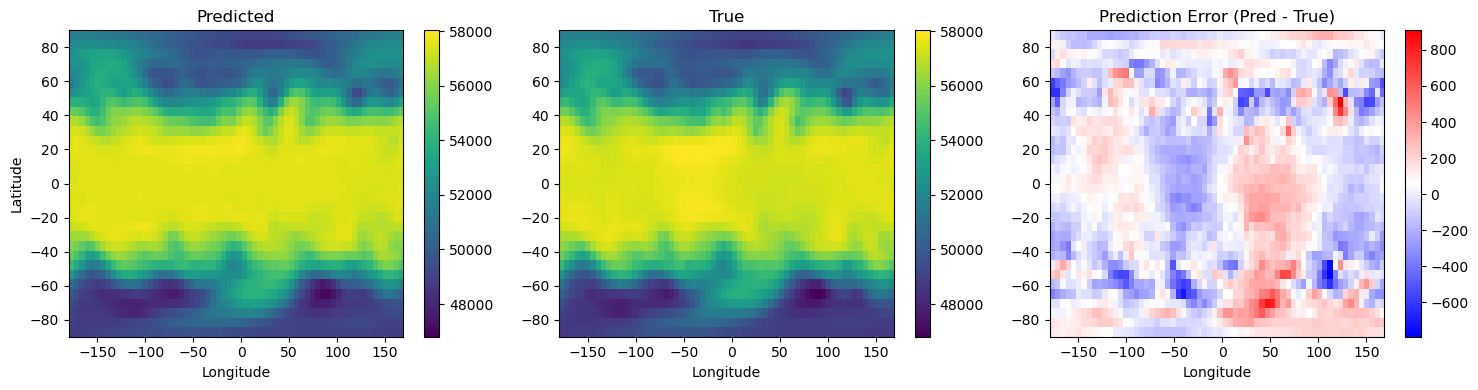

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# Your latitude and longitude arrays from the dataset
latitudes = np.linspace(-90, 90, 64)           # or from ds['latitude'].values
longitudes = np.linspace(0, 360, 32, endpoint=False)
longitudes = (longitudes + 180) % 360 - 180    # Shift to [-180, 180]

# Create extent for imshow: [xmin, xmax, ymin, ymax]
extent = [longitudes.min(), longitudes.max(), latitudes.min(), latitudes.max()]

# Pick a single time index to plot
t = 10

vmin = min(y_pred_grid[t].min(), y_test[t].min())
vmax = max(y_pred_grid[t].max(), y_test[t].max())

plt.figure(figsize=(15, 4))

# 🔹 Predicted
plt.subplot(1, 3, 1)
plt.imshow(y_pred_grid[t].T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax,
           extent=extent, aspect='auto')
plt.title("Predicted")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()

# 🔹 True
plt.subplot(1, 3, 2)
plt.imshow(y_test[t].T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax,
           extent=extent, aspect='auto')
plt.title("True")
plt.xlabel("Longitude")
plt.colorbar()

# 🔹 Difference
plt.subplot(1, 3, 3)
plt.imshow((y_pred_grid[t] - y_test[t].detach().numpy()).T, origin='lower',
           cmap='bwr', extent=extent, aspect='auto')
plt.title("Prediction Error (Pred - True)")
plt.xlabel("Longitude")
plt.colorbar()

plt.tight_layout()
plt.show()
